In [1]:
import numpy as np
import matplotlib.pyplot as plt
import exowrap
from exowrap.output import ExoremOut

# Define an identical baseline planet for the test
# We use a non-zero T_irr to ensure radiation transport is highly active
test_params = {
    "mass": 1.0,
    "T_int": 500,
    "T_irr": 1000, 
    "Met": 0.0,
    "f_sed": 2.0,
    "kzz": 8.0,
    "g_1bar": 10.0
}

In [2]:
print("Running baseline R=50 model... ⏳")
model_50 = exowrap.Simulation(params=test_params, resolution=50)
df_50 = model_50.run()
exo_50 = ExoremOut(df_50)

print("Running high-resolution R=500 model... ⏳")
model_500 = exowrap.Simulation(params=test_params, resolution=500)
df_500 = model_500.run()
exo_500 = ExoremOut(df_500)

print("✅ Both simulations converged successfully!")

INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp72bgbf1m/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


Running baseline R=50 model... ⏳


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmp72bgbf1m/outputs/exowrap_run.h5...
INFO: Simulation complete.
INFO: Starting ExoREM Simulation...
INFO: Generated namelist at /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpggjigg2u/input.nml
INFO: Running Fortran backend from /Users/cwilkinson/.exowrap/exorem_source/dist/dist/exorem/bin...


Running high-resolution R=500 model... ⏳


INFO: Parsing results from /private/var/folders/ld/pl_0zzs158sb8h6_y3mrd0lm0000gp/T/tmpggjigg2u/outputs/exowrap_run.h5...
INFO: Simulation complete.


✅ Both simulations converged successfully!


In [3]:
# 1. Extract the profiles
p_50 = exo_50.pressure_profile
t_50 = exo_50.temperature_profile

p_500 = exo_500.pressure_profile
t_500 = exo_500.temperature_profile

# 2. Sanity Check: Ensure the spatial pressure grids are identical
# (If they aren't, we can't subtract the temperatures layer-by-layer!)
np.testing.assert_allclose(
    p_50, p_500, 
    rtol=1e-5, 
    err_msg="The vertical pressure grids do not match!"
)

# 3. Calculate the absolute temperature difference at every layer
delta_t = t_500 - t_50

max_diff = np.max(np.abs(delta_t))
mean_diff = np.mean(np.abs(delta_t))

print(f"Maximum Temperature Difference: {max_diff:.4f} K")
print(f"Mean Absolute Difference across all layers: {mean_diff:.4f} K")

Maximum Temperature Difference: 4.4317 K
Mean Absolute Difference across all layers: 1.8617 K


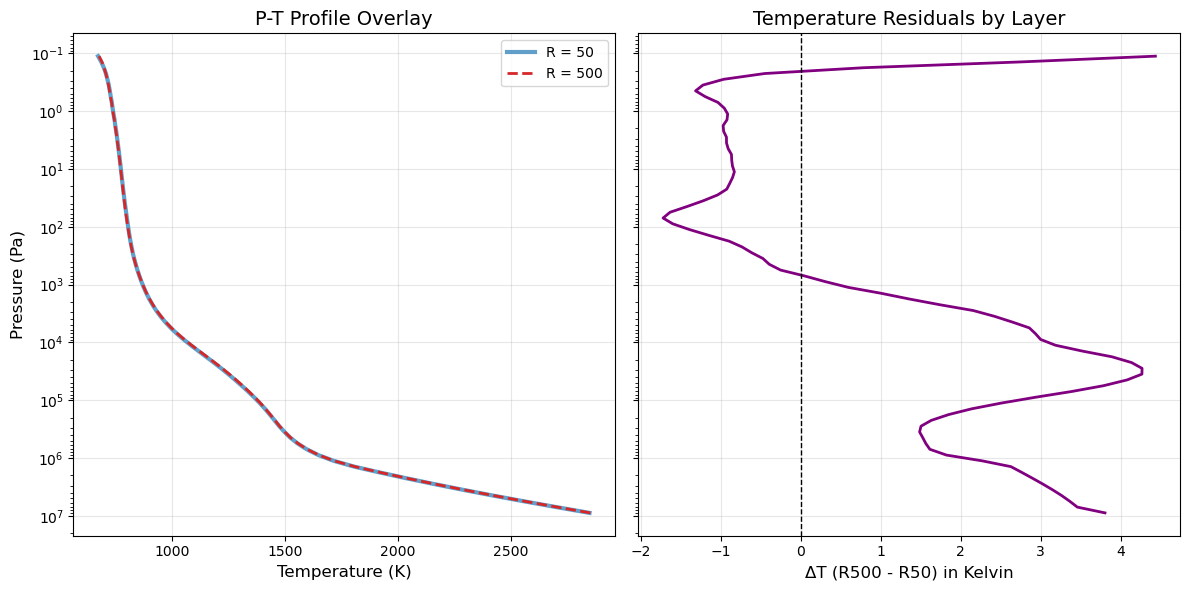

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Panel 1: Standard P-T Overlay
axes[0].plot(t_50, p_50, lw=3, label="R = 50", color="tab:blue", alpha=0.7)
axes[0].plot(t_500, p_500, lw=2, label="R = 500", color="tab:red", linestyle="--")
axes[0].set_yscale("log")
axes[0].invert_yaxis()
axes[0].set_xlabel("Temperature (K)", fontsize=12)
axes[0].set_ylabel("Pressure (Pa)", fontsize=12)
axes[0].set_title("P-T Profile Overlay", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: The Residuals (Delta T)
axes[1].plot(delta_t, p_50, lw=2, color="purple")
axes[1].axvline(0, color="black", linestyle="--", lw=1) # A line at exactly 0 difference
axes[1].set_xlabel("ΔT (R500 - R50) in Kelvin", fontsize=12)
axes[1].set_title("Temperature Residuals by Layer", fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()